# Jena Climate Temperature Forecasting System

This notebook implements a stable, English-only workflow for time series forecasting on the Jena Climate dataset.

The project covers:

1. Data loading, cleaning, and exploratory analysis.
2. Time series preprocessing, chronological splitting, scaling, and memory-safe windowing.
3. Persistence baseline, LSTM training, GRU training, evaluation, and visualization.

The default target is `T (degC)`. The default forecast horizon predicts the next 10-minute temperature value using the previous 24 hours of climate measurements.


## Project Objective

Build a reliable short-horizon temperature forecasting workflow using historical climate measurements. The project evaluates a simple persistence baseline alongside LSTM and GRU neural models, then compares the methods using MAE and RMSE in Celsius.

The notebook is structured as a realistic machine learning forecasting project rather than as a set of assignment tasks.

In [1]:
# ================================
# 0. Runtime, Imports, and Configuration
# ================================

from pathlib import Path
import os

# Stable default: CPU mode avoids CUDA/cuDNN memory errors in notebook environments.
# Set USE_GPU = True only after confirming that TensorFlow, CUDA, and cuDNN are stable.
USE_GPU = False

if not USE_GPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
else:
    os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
    os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional GPU memory growth
if USE_GPU:
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as error:
                print(error)
        print("GPU devices:", gpus)
    else:
        print("No GPU detected. Training will run on CPU.")
else:
    print("CPU mode is enabled for maximum stability.")

# Project paths
OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Forecasting configuration
TARGET_COLUMN = "T (degC)"
FEATURE_COLUMNS = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

WINDOW_SIZE = 144
HORIZON = 1
BATCH_SIZE = 256
EPOCHS = 30

print("TensorFlow version:", tf.__version__)
print("Window size:", WINDOW_SIZE)
print("Forecast horizon:", HORIZON)
print("Batch size:", BATCH_SIZE)

I0000 00:00:1778258629.227612  160574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778258630.300408  160574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


CPU mode is enabled for maximum stability.
TensorFlow version: 2.21.0
Window size: 144
Forecast horizon: 1
Batch size: 256


## Data Ingestion and Exploratory Review

This section loads the dataset, converts the timestamp column into a proper datetime format, handles data quality issues, and visualizes the main climate variables.


In [2]:
# ================================
# Data ingestion and cleaning
# ================================

def resolve_dataset_path(path_candidates):
    """Return the first existing dataset path from a list of candidates."""
    for path in path_candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Dataset not found. Place jena_climate_2009_2016.csv in the project root or data/ folder."
    )


def load_climate_data(path):
    """Load the Jena Climate dataset and parse the Date Time column."""
    data = pd.read_csv(path)
    data["Date Time"] = pd.to_datetime(
        data["Date Time"],
        format="%d.%m.%Y %H:%M:%S",
    )
    data = data.sort_values("Date Time").reset_index(drop=True)
    return data


def clean_climate_data(data):
    """Clean duplicate timestamps, invalid wind values, and missing values."""
    clean_data = data.copy()

    wind_columns = ["wv (m/s)", "max. wv (m/s)"]
    clean_data[wind_columns] = clean_data[wind_columns].replace(-9999, np.nan)

    clean_data = clean_data.set_index("Date Time")
    clean_data = clean_data.groupby(clean_data.index).mean()
    clean_data = clean_data.asfreq("10min")
    clean_data = clean_data.interpolate(method="time")
    clean_data = clean_data.ffill().bfill()

    return clean_data


DATA_PATH = resolve_dataset_path([
    Path("jena_climate_2009_2016.csv"),
    Path("data/jena_climate_2009_2016.csv"),
    Path("/mnt/data/jena_climate_2009_2016.csv"),
])

df = load_climate_data(DATA_PATH)
df_clean = clean_climate_data(df)

print("Dataset path:", DATA_PATH)
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Start date:", df_clean.index.min())
print("End date:", df_clean.index.max())
print("Remaining missing values:", int(df_clean.isna().sum().sum()))

display(df.head())
display(df_clean.head())

Dataset path: data/jena_climate_2009_2016.csv
Original shape: (420551, 15)
Cleaned shape: (420768, 14)
Start date: 2009-01-01 00:10:00
End date: 2017-01-01 00:00:00
Remaining missing values: 0


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# ================================
# Dataset profiling
# ================================

print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe().T)

invalid_counts = (df.select_dtypes(include=["number"]) == -9999).sum()
invalid_counts = invalid_counts[invalid_counts > 0]

print("\nInvalid -9999 values before cleaning:")
display(invalid_counts.to_frame("count"))

print("\nDuplicate timestamps before cleaning:", int(df["Date Time"].duplicated().sum()))

Column names:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date Time        420551 non-null  datetime64[us]
 1   p (mbar)         420551 non-null  float64       
 2   T (degC)         420551 non-null  float64       
 3   Tpot (K)         420551 non-null  float64       
 4   Tdew (degC)      420551 non-null  float64       
 5   rh (%)           420551 non-null  float64       
 6   VPmax (mbar)     420551 non-null  float64       
 7   VPact (mbar)     420551 non-null  float64       
 8   VPdef (mbar)     420551 non-null  float64       
 9   sh (g/kg)        420551 non-null  float64       
 10 

,count,mean,min,25%,50%,75%,max,std
Date Time,420551,2012-12-30 06:26:51.498724,2009-01-01 00:10:00,2010-12-31 03:25:00,2012-12-30 06:20:00,2014-12-29 18:55:00,2017-01-01 00:00:00,NaN
p (mbar),420551.0,989.212776,913.6,984.2,989.58,994.72,1015.35,8.358481
T (degC),420551.0,9.450147,-23.01,3.36,9.42,15.47,37.28,8.423365
Tpot (K),420551.0,283.492743,250.6,277.43,283.47,289.53,311.34,8.504471
Tdew (degC),420551.0,4.955854,-25.01,0.24,5.22,10.07,23.11,6.730674
rh (%),420551.0,76.008259,12.95,65.21,79.3,89.4,100.0,16.476175
VPmax (mbar),420551.0,13.576251,0.95,7.78,11.82,17.6,63.77,7.73902
VPact (mbar),420551.0,9.533756,0.79,6.21,8.86,12.35,28.32,4.184164
VPdef (mbar),420551.0,4.042412,0.0,0.87,2.19,5.3,46.01,4.896851
sh (g/kg),420551.0,6.022408,0.5,3.92,5.59,7.8,18.13,2.656139



Invalid -9999 values before cleaning:


,count
wv (m/s),18
max. wv (m/s),20



Duplicate timestamps before cleaning: 327


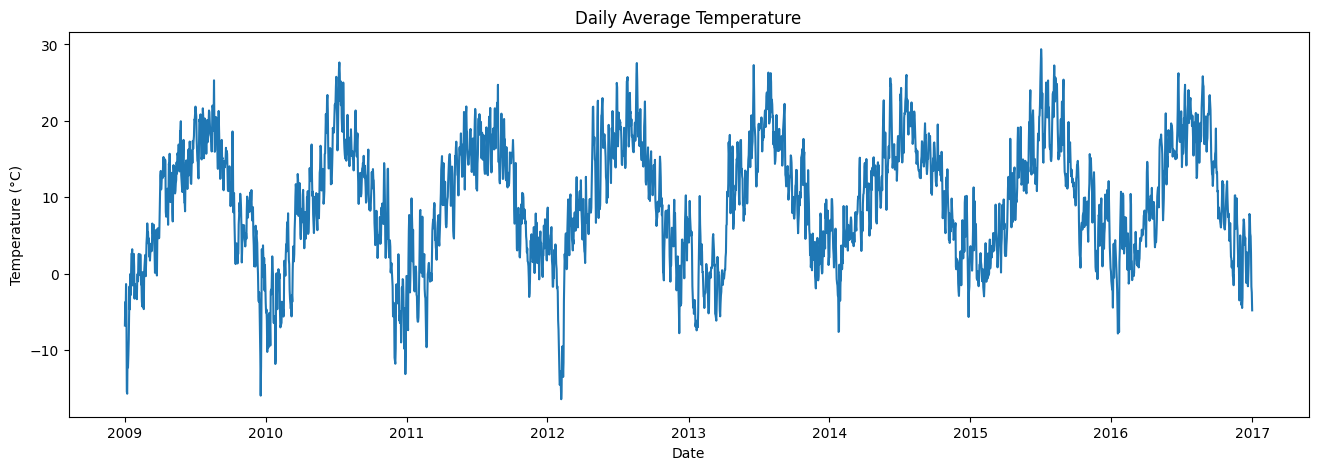

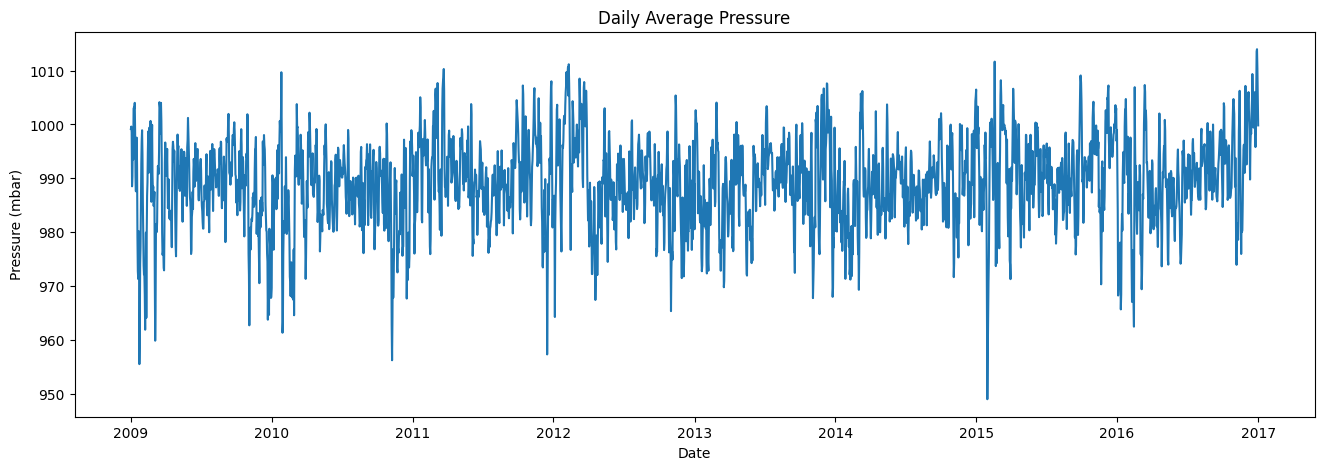

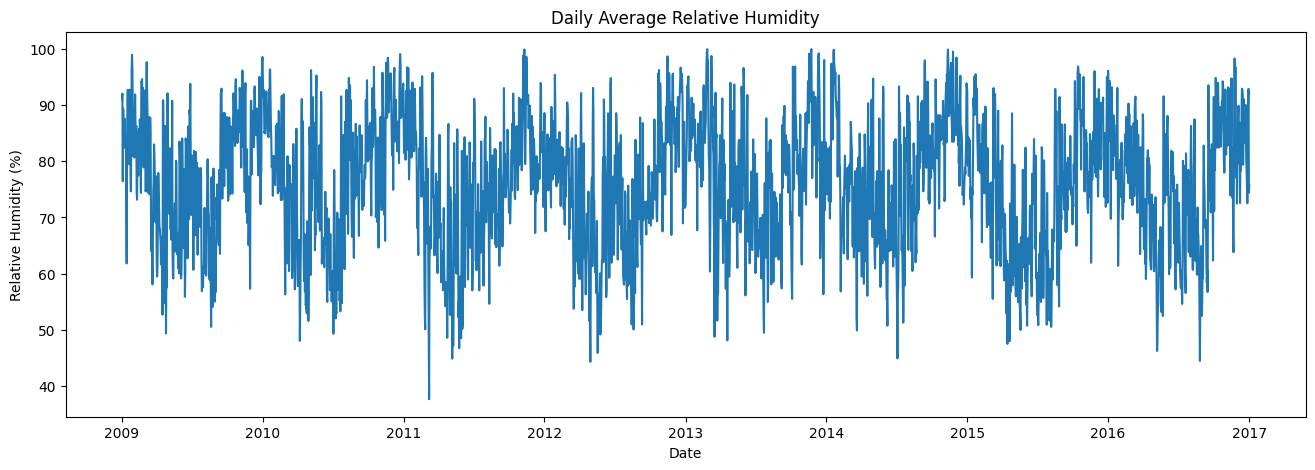

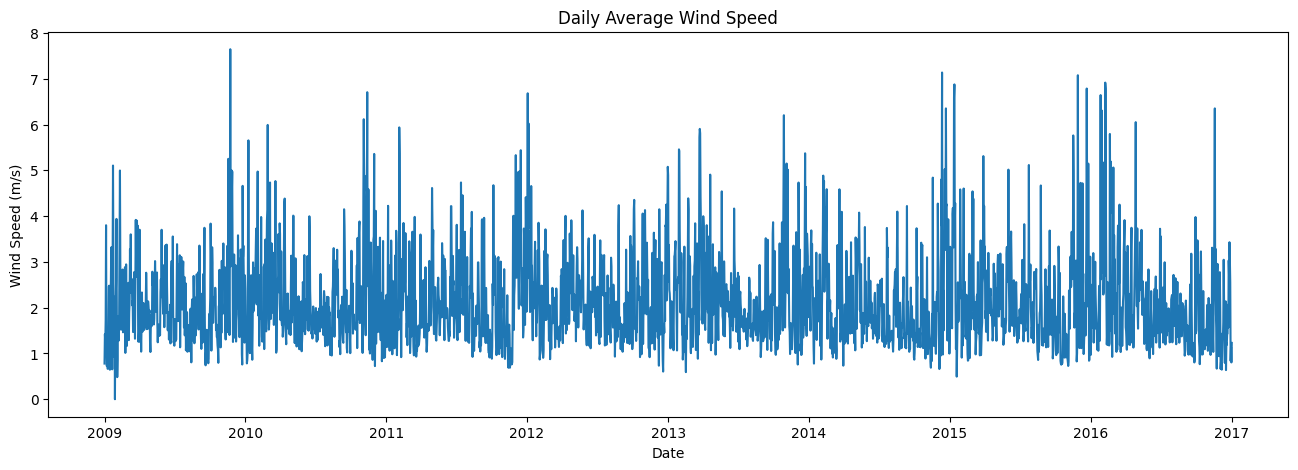

In [4]:
# ================================
# Climate trend visualizations
# ================================

def plot_daily_series(data, column, title, ylabel, save_name=None):
    """Plot daily average values for a selected variable."""
    daily_values = data[column].resample("D").mean()

    plt.figure(figsize=(16, 5))
    plt.plot(daily_values.index, daily_values.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)

    if save_name:
        plt.savefig(PLOT_DIR / save_name, dpi=300, bbox_inches="tight")

    plt.show()


plot_daily_series(df_clean, "T (degC)", "Daily Average Temperature", "Temperature (°C)", "daily_temperature.png")
plot_daily_series(df_clean, "p (mbar)", "Daily Average Pressure", "Pressure (mbar)", "daily_pressure.png")
plot_daily_series(df_clean, "rh (%)", "Daily Average Relative Humidity", "Relative Humidity (%)", "daily_humidity.png")
plot_daily_series(df_clean, "wv (m/s)", "Daily Average Wind Speed", "Wind Speed (m/s)", "daily_wind_speed.png")

,correlation_with_temperature
T (degC),1.000000
Tpot (K),0.996818
VPmax (mbar),0.951060
Tdew (degC),0.895924
VPact (mbar),0.867958
H2OC (mmol/mol),0.867458
sh (g/kg),0.867037
VPdef (mbar),0.761392
max. wv (m/s),0.124783
wv (m/s),0.088113


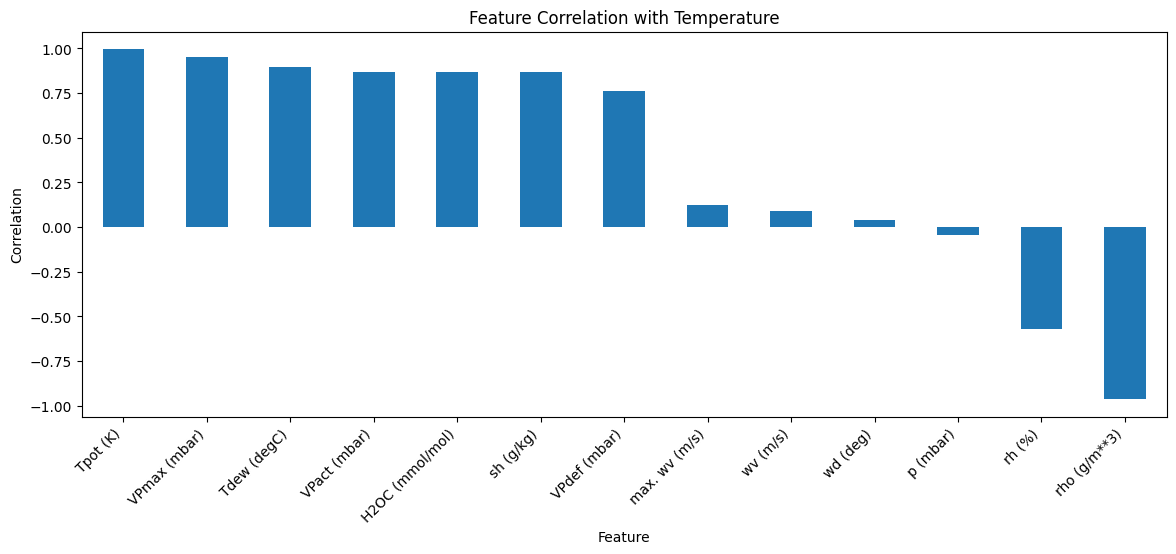

In [5]:
# ================================
# Feature correlation review
# ================================

correlation_with_temperature = (
    df_clean
    .corr(numeric_only=True)[TARGET_COLUMN]
    .sort_values(ascending=False)
)

display(correlation_with_temperature.to_frame("correlation_with_temperature"))

plt.figure(figsize=(14, 5))
correlation_with_temperature.drop(TARGET_COLUMN).plot(kind="bar")
plt.title("Feature Correlation with Temperature")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.savefig(PLOT_DIR / "feature_correlation_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

## Preprocessing and Forecast Window Design

This section performs chronological splitting, scaling without data leakage, and memory-safe sliding-window generation.

A custom `PyDataset` is used instead of `timeseries_dataset_from_array` or `tf.data.Dataset.from_generator`. This avoids pushing the full source array to the GPU as a large TensorFlow constant and is more stable in notebook environments.


In [6]:
# ================================
# Feature selection and chronological split
# ================================

missing_columns = [column for column in FEATURE_COLUMNS if column not in df_clean.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df_model = df_clean[FEATURE_COLUMNS].copy()

n_rows = len(df_model)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_df = df_model.iloc[:train_end]
val_df = df_model.iloc[train_end:val_end]
test_df = df_model.iloc[val_end:]

print("Total rows:", n_rows)
print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Testing rows:", len(test_df))

print("\nTrain period:", train_df.index.min(), "to", train_df.index.max())
print("Validation period:", val_df.index.min(), "to", val_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())

Total rows: 420768
Training rows: 294537
Validation rows: 63115
Testing rows: 63116

Train period: 2009-01-01 00:10:00 to 2014-08-08 09:30:00
Validation period: 2014-08-08 09:40:00 to 2015-10-20 16:40:00
Test period: 2015-10-20 16:50:00 to 2017-01-01 00:00:00


In [7]:
# ================================
# Scaling without data leakage
# ================================

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS]).astype(np.float32)
train_target_scaled = target_scaler.fit_transform(train_df[[TARGET_COLUMN]]).astype(np.float32)

val_features_scaled = feature_scaler.transform(val_df[FEATURE_COLUMNS]).astype(np.float32)
val_target_scaled = target_scaler.transform(val_df[[TARGET_COLUMN]]).astype(np.float32)

test_features_scaled = feature_scaler.transform(test_df[FEATURE_COLUMNS]).astype(np.float32)
test_target_scaled = target_scaler.transform(test_df[[TARGET_COLUMN]]).astype(np.float32)

print("Train features:", train_features_scaled.shape)
print("Validation features:", val_features_scaled.shape)
print("Test features:", test_features_scaled.shape)

Train features: (294537, 14)
Validation features: (63115, 14)
Test features: (63116, 14)


In [8]:
# ================================
# Memory-safe forecasting datasets
# ================================

class TimeSeriesWindowDataset(tf.keras.utils.PyDataset):
    """Memory-safe Keras dataset for sliding-window time series forecasting."""

    def __init__(
        self,
        features,
        target,
        window_size,
        horizon,
        batch_size,
        shuffle=False,
        seed=42,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.features = np.asarray(features, dtype=np.float32)
        self.target = np.asarray(target, dtype=np.float32)
        self.window_size = int(window_size)
        self.horizon = int(horizon)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)
        self.rng = np.random.default_rng(self.seed)

        if len(self.features) <= self.window_size + self.horizon:
            raise ValueError("Not enough rows to create time series windows.")

        self.max_start = len(self.features) - self.window_size - self.horizon + 1
        self.indices = np.arange(self.max_start, dtype=np.int64)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.max_start / self.batch_size))

    def __getitem__(self, batch_index):
        batch_indices = self.indices[
            batch_index * self.batch_size : (batch_index + 1) * self.batch_size
        ]

        X = np.empty(
            (len(batch_indices), self.window_size, self.features.shape[1]),
            dtype=np.float32,
        )
        y = np.empty((len(batch_indices), self.target.shape[1]), dtype=np.float32)

        for row_index, start in enumerate(batch_indices):
            end = start + self.window_size
            target_index = end + self.horizon - 1
            X[row_index] = self.features[start:end]
            y[row_index] = self.target[target_index]

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)


def make_timeseries_dataset(features, target, window_size, horizon, batch_size, shuffle=False):
    """Create a memory-safe time series dataset."""
    return TimeSeriesWindowDataset(
        features=features,
        target=target,
        window_size=window_size,
        horizon=horizon,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=SEED,
        workers=1,
        use_multiprocessing=False,
        max_queue_size=2,
    )


train_ds = make_timeseries_dataset(
    train_features_scaled,
    train_target_scaled,
    WINDOW_SIZE,
    HORIZON,
    BATCH_SIZE,
    shuffle=True,
)

val_ds = make_timeseries_dataset(
    val_features_scaled,
    val_target_scaled,
    WINDOW_SIZE,
    HORIZON,
    BATCH_SIZE,
    shuffle=False,
)

test_ds = make_timeseries_dataset(
    test_features_scaled,
    test_target_scaled,
    WINDOW_SIZE,
    HORIZON,
    BATCH_SIZE,
    shuffle=False,
)

X_batch, y_batch = train_ds[0]
input_shape = (X_batch.shape[1], X_batch.shape[2])

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)
print("Model input shape:", input_shape)

X batch shape: (256, 144, 14)
y batch shape: (256, 1)
Model input shape: (144, 14)


In [9]:
# ================================
# Forecast window validation
# ================================

def count_windows(data_length, window_size, horizon):
    """Return the number of windows created from one split."""
    return data_length - window_size - horizon + 1


train_windows = count_windows(len(train_df), WINDOW_SIZE, HORIZON)
val_windows = count_windows(len(val_df), WINDOW_SIZE, HORIZON)
test_windows = count_windows(len(test_df), WINDOW_SIZE, HORIZON)

print("Training windows:", train_windows)
print("Validation windows:", val_windows)
print("Testing windows:", test_windows)

temperature_index = FEATURE_COLUMNS.index(TARGET_COLUMN)

X_check, y_check = train_ds[0]
last_input_temperature = X_check[:, -1, temperature_index]
target_temperature = y_check[:, 0]

print("\nExact equality between last input temperature and target:")
print(bool(np.allclose(last_input_temperature, target_temperature)))

Training windows: 294393
Validation windows: 62971
Testing windows: 62972

Exact equality between last input temperature and target:
False


## Baseline and Recurrent Forecasting Models

This section trains two recurrent neural network models and compares them against a persistence baseline.

The persistence baseline predicts the next temperature as the last known temperature in the input window. This is important because a 10-minute-ahead temperature forecast can be very close to the current temperature.


In [10]:
# ================================
# Persistence baseline
# ================================

def collect_targets(dataset):
    """Collect true target values from a Keras dataset."""
    targets = []
    for batch_index in range(len(dataset)):
        _, y_batch = dataset[batch_index]
        targets.append(y_batch)
    return np.concatenate(targets, axis=0)


def calculate_metrics(y_true, y_pred):
    """Calculate MAE and RMSE in Celsius."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


def evaluate_persistence_baseline(dataset, target_scaler, temperature_index):
    """Predict the future temperature as the last observed temperature in the input window."""
    y_true_scaled = []
    baseline_pred_scaled = []

    for batch_index in range(len(dataset)):
        X_batch, y_batch = dataset[batch_index]
        last_temperature = X_batch[:, -1, temperature_index].reshape(-1, 1)
        baseline_pred_scaled.append(last_temperature)
        y_true_scaled.append(y_batch)

    y_true_scaled = np.concatenate(y_true_scaled, axis=0)
    baseline_pred_scaled = np.concatenate(baseline_pred_scaled, axis=0)

    y_true_celsius = target_scaler.inverse_transform(y_true_scaled)
    baseline_pred_celsius = target_scaler.inverse_transform(baseline_pred_scaled)

    mae, rmse = calculate_metrics(y_true_celsius, baseline_pred_celsius)
    return mae, rmse, y_true_celsius, baseline_pred_celsius


baseline_mae, baseline_rmse, y_test_celsius, baseline_pred_celsius = evaluate_persistence_baseline(
    test_ds,
    target_scaler,
    temperature_index,
)

print("Persistence Baseline MAE (°C):", baseline_mae)
print("Persistence Baseline RMSE (°C):", baseline_rmse)

Persistence Baseline MAE (°C): 0.15639887750148773
Persistence Baseline RMSE (°C): 0.23591312509903756


In [11]:
# ================================
# Stable recurrent model architecture
# ================================

def make_recurrent_layer(cell_type, units):
    """Create an LSTM or GRU layer with a CPU/GPU-stable configuration."""
    cell_type = cell_type.lower()

    common_kwargs = {
        "units": units,
        "return_sequences": False,
        "kernel_regularizer": l2(1e-5),
        "recurrent_regularizer": l2(1e-5),
    }

    if cell_type == "lstm":
        try:
            return LSTM(**common_kwargs, use_cudnn=False)
        except TypeError:
            return LSTM(**common_kwargs)

    if cell_type == "gru":
        try:
            return GRU(**common_kwargs, use_cudnn=False)
        except TypeError:
            return GRU(**common_kwargs)

    raise ValueError("cell_type must be either 'lstm' or 'gru'.")


def build_recurrent_model(input_shape, cell_type):
    """Build a stable regularized LSTM or GRU forecasting model."""
    model = Sequential([
        Input(shape=input_shape),
        make_recurrent_layer(cell_type, units=32),
        Dropout(0.15),
        Dense(16, activation="relu", kernel_regularizer=l2(1e-5)),
        Dropout(0.10),
        Dense(1),
    ], name=cell_type.upper())

    model.compile(
        optimizer=Adam(learning_rate=3e-4, clipnorm=1.0),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

    return model

In [12]:
# ================================
# Training callbacks
# ================================

def create_callbacks(model_name):
    """Create callbacks and return the path used for best model weights."""
    weights_path = MODEL_DIR / f"best_{model_name.lower()}.weights.h5"

    callbacks = [
        EarlyStopping(
            monitor="val_rmse",
            mode="min",
            patience=5,
            min_delta=1e-4,
            restore_best_weights=True,
        ),
        ModelCheckpoint(
            filepath=weights_path,
            monitor="val_rmse",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
        ),
        ReduceLROnPlateau(
            monitor="val_rmse",
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ),
    ]

    return callbacks, weights_path

In [13]:
# ================================
# Train recurrent models one at a time
# ================================

histories = {}
trained_models = {}
best_weight_paths = {}

model_specs = {
    "LSTM": "lstm",
    "GRU": "gru",
}

for model_name, cell_type in model_specs.items():
    print("=" * 60)
    print(f"Training {model_name} model")
    print("=" * 60)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_recurrent_model(input_shape, cell_type)
    model.summary()

    callbacks, weights_path = create_callbacks(model_name)
    best_weight_paths[model_name] = weights_path

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    if weights_path.exists():
        model.load_weights(weights_path)
        print(f"Loaded best weights for {model_name} from {weights_path}")

    histories[model_name] = history
    trained_models[model_name] = model

Training LSTM model


E0000 00:00:1778258635.915164  160574 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,561 (25.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 77s 66ms/step - loss: 0.0766 - mae: 0.1785 - rmse: 0.2754 - val_loss: 0.0044 - val_mae: 0.0469 - val_rmse: 0.0600 - learning_rate: 3.0000e-04
Epoch 2/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - loss: 0.0287 - mae: 0.1151 - rmse: 0.1672 - val_loss: 0.0035 - val_mae: 0.0366 - val_rmse: 0.0523 - learning_rate: 3.0000e-04
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 74s 65ms/step - loss: 0.0240 - mae: 0.1041 - rmse: 0.1525 - val_loss: 0.0028 - val_mae: 0.0345 - val_rmse: 0.0459 - learning_rate: 3.0000e-04
Epoch 4/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 75s 66ms/step - loss: 0.0224 - mae: 0.0998 - rmse: 0.1474 - val_loss: 0.0034 - val_mae: 0.0372 - val_rmse: 0.0522 - learning_rate: 3.0000e-04
Epoch 5/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 71s 62ms/step - loss: 0.0217 - mae: 0.0978 - rmse: 0.1452 - val_loss: 0.0019 - val_mae: 0.0262 - val_rmse: 0.0366 - learning_rate: 3.0000e-04
Epoch 6/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 70s 61ms/step - loss: 0.0210 - mae: 0.

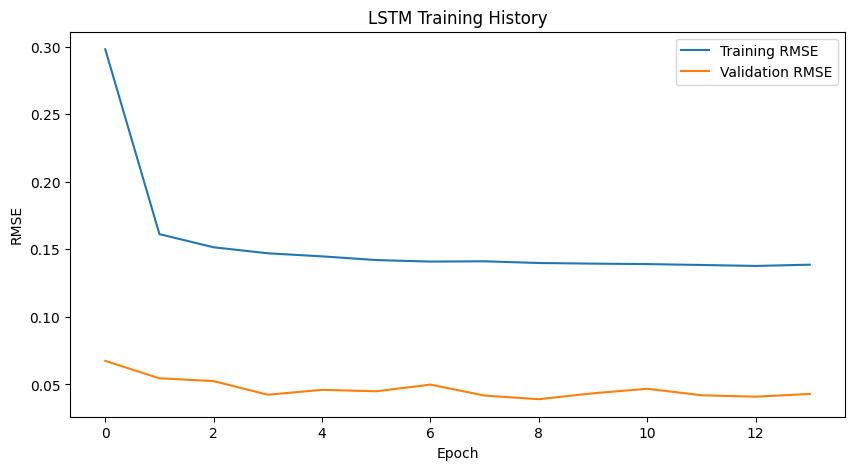

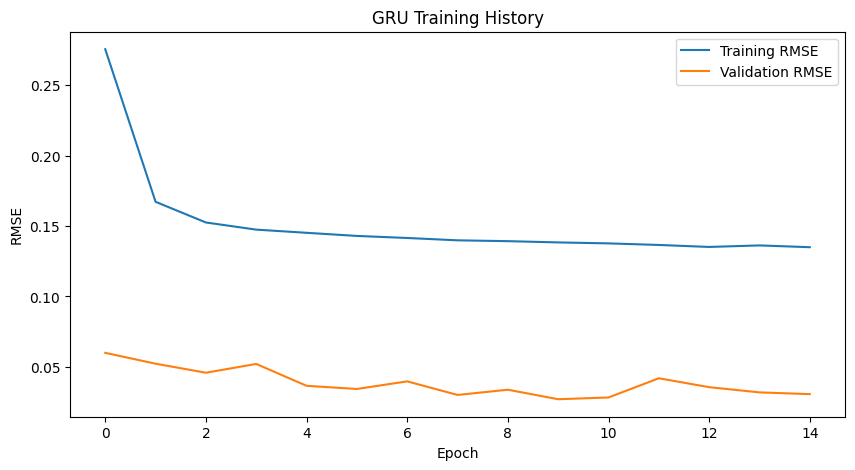

In [14]:
# ================================
# Training curve visualization
# ================================

def plot_training_history(history, model_name):
    """Plot training and validation RMSE for one model."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["rmse"], label="Training RMSE")
    plt.plot(history.history["val_rmse"], label="Validation RMSE")
    plt.title(f"{model_name} Training History")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.legend()
    plt.savefig(PLOT_DIR / f"{model_name.lower()}_training_history.png", dpi=300, bbox_inches="tight")
    plt.show()


for model_name, history in histories.items():
    plot_training_history(history, model_name)

In [15]:
# ================================
# Train, validation, and test evaluation
# ================================

def evaluate_scaled_datasets(model, model_name, datasets):
    """Evaluate a model on multiple datasets with dropout disabled."""
    rows = []

    for split_name, dataset in datasets.items():
        metrics = model.evaluate(dataset, verbose=0, return_dict=True)
        rows.append({
            "Model": model_name,
            "Dataset": split_name,
            "Loss": metrics["loss"],
            "MAE": metrics["mae"],
            "RMSE": metrics["rmse"],
        })

    return rows


scaled_evaluation_rows = []
datasets = {
    "Train": train_ds,
    "Validation": val_ds,
    "Test": test_ds,
}

for model_name, model in trained_models.items():
    scaled_evaluation_rows.extend(evaluate_scaled_datasets(model, model_name, datasets))

scaled_evaluation_df = pd.DataFrame(scaled_evaluation_rows)
display(scaled_evaluation_df)

,Model,Dataset,Loss,MAE,RMSE
0,LSTM,Train,0.002240,0.028297,0.039647
1,LSTM,Validation,0.002197,0.027108,0.039103
2,LSTM,Test,0.002093,0.026544,0.037754
3,GRU,Train,0.001307,0.020597,0.028714
4,GRU,Validation,0.001218,0.018797,0.027132
5,GRU,Test,0.001174,0.018624,0.026303


In [16]:
# ================================
# Final test evaluation in Celsius
# ================================

predictions = {}
results = [
    {
        "Model": "Persistence Baseline",
        "Test MAE (°C)": baseline_mae,
        "Test RMSE (°C)": baseline_rmse,
    }
]

for model_name, model in trained_models.items():
    print(f"\nGenerating predictions for {model_name}...")

    pred_scaled = model.predict(test_ds, verbose=0)
    pred_celsius = target_scaler.inverse_transform(pred_scaled)

    predictions[model_name] = pred_celsius

    mae, rmse = calculate_metrics(y_test_celsius, pred_celsius)

    results.append({
        "Model": model_name,
        "Test MAE (°C)": mae,
        "Test RMSE (°C)": rmse,
    })

results_df = pd.DataFrame(results).sort_values("Test RMSE (°C)").reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model based on test RMSE: {best_model_name}")


Generating predictions for LSTM...

Generating predictions for GRU...


,Model,Test MAE (°C),Test RMSE (°C)
0,GRU,0.161125,0.227562
1,Persistence Baseline,0.156399,0.235913
2,LSTM,0.229640,0.326621


Best model based on test RMSE: GRU


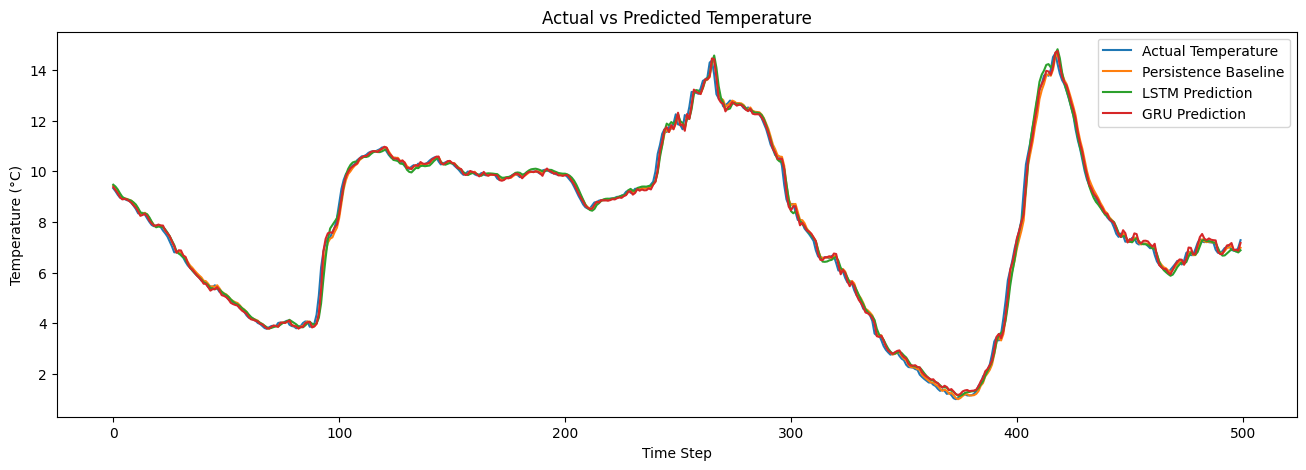

In [17]:
# ================================
# Actual vs predicted visualization
# ================================

PLOT_POINTS = 500

plt.figure(figsize=(16, 5))
plt.plot(y_test_celsius[:PLOT_POINTS], label="Actual Temperature")
plt.plot(baseline_pred_celsius[:PLOT_POINTS], label="Persistence Baseline")

for model_name, pred_values in predictions.items():
    plt.plot(pred_values[:PLOT_POINTS], label=f"{model_name} Prediction")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.savefig(PLOT_DIR / "actual_vs_predicted_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# ================================
# Save project artifacts
# ================================

results_path = OUTPUT_DIR / "model_comparison_results.csv"
scaled_evaluation_path = OUTPUT_DIR / "scaled_dataset_evaluation.csv"
predictions_path = OUTPUT_DIR / "temperature_predictions.csv"

results_df.to_csv(results_path, index=False)
scaled_evaluation_df.to_csv(scaled_evaluation_path, index=False)

predictions_df = pd.DataFrame({
    "actual_temperature": y_test_celsius.flatten(),
    "baseline_prediction": baseline_pred_celsius.flatten(),
})

for model_name, pred_values in predictions.items():
    predictions_df[f"{model_name.lower()}_prediction"] = pred_values.flatten()

predictions_df.to_csv(predictions_path, index=False)

print("Saved model comparison results to:", results_path)
print("Saved scaled dataset evaluation to:", scaled_evaluation_path)
print("Saved predictions to:", predictions_path)

display(predictions_df.head())

Saved model comparison results to: outputs/model_comparison_results.csv
Saved scaled dataset evaluation to: outputs/scaled_dataset_evaluation.csv
Saved predictions to: outputs/temperature_predictions.csv


,actual_temperature,baseline_prediction,lstm_prediction,gru_prediction
0,9.33,9.43,9.469323,9.375910
1,9.21,9.33,9.394547,9.248154
2,9.07,9.21,9.279261,9.126055
3,8.96,9.07,9.125125,8.968938
4,8.93,8.96,8.990244,8.889569


In [19]:
# ================================
# Visualization, Reporting, and Documentation
# ================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "reports"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [30]:
def save_plot(filename):
    """
    Save the current matplotlib figure to the plots directory.
    """
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path}")

In [31]:
def save_plot(filename):
    """
    Save the current matplotlib figure to the plots directory.
    """
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path}")

In [32]:
model_results_path = OUTPUT_DIR / "model_comparison_results.csv"
scaled_eval_path = OUTPUT_DIR / "scaled_dataset_evaluation.csv"
predictions_path = OUTPUT_DIR / "temperature_predictions.csv"

model_results = pd.read_csv(model_results_path)
scaled_evaluation = pd.read_csv(scaled_eval_path)
predictions = pd.read_csv(predictions_path)

print("Model comparison results:")
display(model_results)

print("Scaled dataset evaluation:")
display(scaled_evaluation)

print("Prediction samples:")
display(predictions.head())

Model comparison results:


,Model,Test MAE (°C),Test RMSE (°C)
0,GRU,0.161125,0.227562
1,Persistence Baseline,0.156399,0.235913
2,LSTM,0.229640,0.326621


Scaled dataset evaluation:


,Model,Dataset,Loss,MAE,RMSE
0,LSTM,Train,0.002240,0.028297,0.039647
1,LSTM,Validation,0.002197,0.027108,0.039103
2,LSTM,Test,0.002093,0.026544,0.037754
3,GRU,Train,0.001307,0.020597,0.028714
4,GRU,Validation,0.001218,0.018797,0.027132
5,GRU,Test,0.001174,0.018624,0.026303


Prediction samples:


,actual_temperature,baseline_prediction,lstm_prediction,gru_prediction
0,9.33,9.43,9.469323,9.375910
1,9.21,9.33,9.394547,9.248154
2,9.07,9.21,9.279261,9.126055
3,8.96,9.07,9.125125,8.968938
4,8.93,8.96,8.990244,8.889569


In [33]:
best_by_mae = model_results.loc[
    model_results["Test MAE (°C)"].idxmin()
]

best_by_rmse = model_results.loc[
    model_results["Test RMSE (°C)"].idxmin()
]

print("Best model by MAE:")
print(best_by_mae)

print("\nBest model by RMSE:")
print(best_by_rmse)

Best model by MAE:
Model             Persistence Baseline
Test MAE (°C)                 0.156399
Test RMSE (°C)                0.235913
Name: 1, dtype: object

Best model by RMSE:
Model                  GRU
Test MAE (°C)     0.161125
Test RMSE (°C)    0.227562
Name: 0, dtype: object


In [28]:
def get_metric(results_df, model_name, metric_name):
    """
    Extract a metric value from the model comparison table.
    """
    value = results_df.loc[
        results_df["Model"] == model_name,
        metric_name
    ]

    if value.empty:
        return None

    return float(value.iloc[0])


baseline_mae = get_metric(model_results, "Persistence Baseline", "Test MAE (°C)")
baseline_rmse = get_metric(model_results, "Persistence Baseline", "Test RMSE (°C)")

lstm_mae = get_metric(model_results, "LSTM", "Test MAE (°C)")
lstm_rmse = get_metric(model_results, "LSTM", "Test RMSE (°C)")

gru_mae = get_metric(model_results, "GRU", "Test MAE (°C)")
gru_rmse = get_metric(model_results, "GRU", "Test RMSE (°C)")


report_text = f"""
# Time Series Forecasting on the Jena Climate Dataset

## 1. Introduction

This project focuses on forecasting future temperature values using historical climate measurements from the Jena Climate dataset. Since the data is sequential and collected over time, recurrent neural network models such as LSTM and GRU were used to learn temporal patterns.

The main target variable was `T (degC)`, which represents temperature in Celsius.

## 2. Dataset Overview

The dataset contains climate measurements collected at regular 10-minute intervals. The main variables include temperature, pressure, humidity, wind speed, wind direction, vapor pressure, air density, and related atmospheric features.

Exploratory data analysis showed clear seasonal patterns in temperature. Temperature values rise during warmer periods and decrease during colder periods, which confirms that the dataset has strong temporal and seasonal behavior.

## 3. Data Cleaning and Preprocessing

The `Date Time` column was converted into a datetime format and used as the time index. Invalid placeholder values in wind speed columns were handled before modeling.

The dataset was split chronologically into training, validation, and test sets to preserve the time order and avoid data leakage.

Standardization was applied using statistics learned from the training data only. The same scalers were then applied to the validation and test sets.

## 4. Time Series Windowing

A sliding window approach was used to transform the time series into supervised learning samples.

The input window size was set to 144 time steps. Since the dataset is recorded every 10 minutes, 144 steps represent one full day of historical observations.

The forecast horizon was set to 1 time step, meaning the models predict the temperature 10 minutes ahead.

## 5. Model Architectures

Two recurrent neural network models were implemented:

- LSTM model
- GRU model

Both models used recurrent layers followed by dropout and dense layers. Dropout and L2 regularization were used to reduce overfitting.

The models were trained using the Adam optimizer and Mean Squared Error loss. Early stopping, model checkpointing, and learning rate reduction were used during training.

## 6. Evaluation Results

The models were evaluated using MAE and RMSE after converting predictions back to Celsius.

| Model | Test MAE (°C) | Test RMSE (°C) |
|---|---:|---:|
| Persistence Baseline | {baseline_mae:.6f} | {baseline_rmse:.6f} |
| LSTM | {lstm_mae:.6f} | {lstm_rmse:.6f} |
| GRU | {gru_mae:.6f} | {gru_rmse:.6f} |

The GRU model achieved the lowest RMSE, which means it was better at reducing larger forecasting errors. The persistence baseline achieved a slightly lower MAE than GRU, which is expected because the forecast horizon is only one step ahead.

The LSTM model performed worse than both the GRU model and the persistence baseline.

## 7. Visualization Analysis

The actual-vs-predicted plot shows that all methods follow the general temperature trend closely. This is expected because the forecast horizon is only 10 minutes ahead.

The GRU model tracks the actual temperature more accurately than the LSTM model, especially during sharper changes. The persistence baseline is also very strong because temperature usually changes gradually over short time intervals.

## 8. Challenges

The main technical challenge was managing memory and GPU stability while training recurrent models on a large time series dataset. A memory-safe dataset pipeline was used to avoid large TensorFlow tensor allocation issues.

Another important modeling challenge was the strength of the persistence baseline. Since the prediction horizon is very short, a simple baseline can be highly competitive.

## 9. Future Improvements

Future improvements could include:

- Predicting further into the future, such as 1 hour ahead or 24 hours ahead.
- Adding cyclic time features such as hour-of-day and day-of-year.
- Testing deeper or bidirectional recurrent architectures.
- Comparing against non-neural models such as Random Forest, XGBoost, or ARIMA.
- Performing feature selection to remove highly redundant climate variables.
- Training models on longer forecast horizons where recurrent models may show stronger advantages.

## 10. Conclusion

This project successfully implemented and compared LSTM and GRU models for temperature forecasting on the Jena Climate dataset.

The GRU model achieved the best RMSE on the test set, making it the strongest neural model in this experiment. However, the persistence baseline remained highly competitive due to the short 10-minute forecasting horizon.

Overall, the results show that recurrent neural networks can model climate time series effectively, but baseline comparison is essential for interpreting forecasting performance correctly.
"""

report_path = REPORTS_DIR / "forecasting_report.md"
report_path.write_text(report_text, encoding="utf-8")

print(f"Report saved to: {report_path}")

Report saved to: outputs/reports/forecasting_report.md
